In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
import torch.nn as nn
np.random.seed(42)
torch.manual_seed(42)
file_path = "../../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
def preprocesss(file_path,seq_len=50):
    dat = np.load(file_path)[:,4000:8000,:] 
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  # Now (timesteps, 53, 3)
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    data = data.reshape(data.shape[0]//seq_len, seq_len, 53*3)
    data = torch.tensor(data,dtype=torch.float)
    return data
data=preprocesss(file_path)
data.shape

torch.Size([80, 50, 159])

In [3]:
class MotionAutoencoder(nn.Module):
    def __init__(self, seq_len=40, input_dim=159, latent_dim=64):
        super(MotionAutoencoder, self).__init__()
        
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(seq_len * input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, seq_len * input_dim)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.reshape(batch_size, self.seq_len, self.input_dim)
        
        return reconstruction, z
    
    def encode(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        return self.encoder(x)
    
    def decode(self, z):
        batch_size = z.shape[0]
        reconstruction = self.decoder(z)
        return reconstruction.reshape(batch_size, self.seq_len, self.input_dim)

In [48]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]
def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 0:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines, show_points=True)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                # point_size=0
                # point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(0.50) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")
def visualize(one_seq,filename='temppp'):
    path = os.path.join("../../src/ train_dance_text_model/animation", f"{filename}")
    inp = np.array(one_seq.detach().reshape(one_seq.shape[0],53,3))
    generate_skeleton_animation(inp,output_name=path)

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer

class TextMapper(nn.Module):
    def __init__(self, text_embedding_dim=768, latent_dim=64, dropout_rate=0.0000):
        super(TextMapper, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(text_embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, latent_dim),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        return self.model(x)

# Load pretrained BERT model & tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

def get_bert_embedding(text):
    tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=50)
    with torch.no_grad():
        output = bert_model(**tokens)
    return output.last_hidden_state[:, 0, :]  # CLS token representation
    
model = MotionAutoencoder(seq_len=50, input_dim=159, latent_dim=64)
model.load_state_dict(torch.load('../../src/ train_dance_text_model/saved_models/best_autoencoder.pth'))
print("Best model loaded.")
motion_autoencoder = model 
motion_autoencoder.eval()
for param in motion_autoencoder.parameters():
    param.requires_grad = False
text_mapper = TextMapper()

Best model loaded.


In [400]:
all_labels = ['spin with little hand movement',
 'spin with right hand above',
 'lifting legs while one hand swinging',
 'arm wave',
 'slowly moving both hands up',
 'both hands in the air',
 'bending down',
 'neck rotation',
 'lying down',
 'twisting while lying down',
 'twisting while lying down',
 'spin with right hand above',
 'neck rotation',
 'neck rotation',
 'slowly moving both hands up',
 'both hands in the air',
 'slowly moving both hands up',
 'spin with right hand above',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'both hands in the air',
 'spin with right hand above',
 'neck rotation',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'lying down',
 'lying down',
 'bending down',
 'bending down',
 'lying down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'slowly moving both hands up',
 'slowly moving both hands up',
 'slowly moving both hands up',
 'slowly moving both hands up',
 'lifting legs while one hand swinging',
 'lifting legs while one hand swinging',
 'lifting legs while one hand swinging',
 'slowly moving both hands up',
 'arm wave',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'lying down',
 'spin with right hand above',
 'slowly moving both hands up',
 'bending down',
 'bending down',
 'neck rotation',
 'neck rotation',
 'bending down',
 'neck rotation',
 'slowly moving both hands up',
 'both hands in the air',
 'spin with right hand above',
 'bending down',
 'bending down',
 'bending down']

In [482]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_text_mapper(text_mapper, motion_autoencoder, data, get_bert_embedding, all_labels, epochs=40, lr=0.01, noise_std=0.01, save_path="saved_models/best_text_mapper.pth"):
    set_seed(42)  # Set the seed at the start of training

    optimizer = optim.Adam(text_mapper.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    text_samples = all_labels[:8]  # 8 training examples
    text_emb = torch.cat([get_bert_embedding(text) for text in text_samples], dim=0)

    best_loss = float("inf")

    for epoch in tqdm(range(epochs), desc="Training Progress"):
        torch.manual_seed(42 + epoch)  # Make noise deterministic per epoch
        text_emb_noisy = text_emb + torch.randn_like(text_emb) * noise_std  
        dance_emb = data[:8] 
        
        with torch.no_grad():
            dance_latent = motion_autoencoder.encode(dance_emb)
        
        text_latent = text_mapper(text_emb_noisy)
        loss = criterion(text_latent, dance_latent)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(text_mapper.state_dict(), save_path)
            print('saved , min loss till now ', best_loss)

In [1529]:
text_mapper = TextMapper()

In [1531]:
set_seed(42)

In [1533]:
train_text_mapper(text_mapper,motion_autoencoder,data,get_bert_embedding,all_labels,epochs=200,lr=0.1) #70,0.0001

Training Progress:  16%|██████████▍                                                      | 32/200 [00:00<00:00, 312.45it/s]

saved , min loss till now  11.905729293823242
saved , min loss till now  11.870010375976562
saved , min loss till now  11.824485778808594
saved , min loss till now  11.778825759887695
saved , min loss till now  11.733057022094727
saved , min loss till now  11.687203407287598
saved , min loss till now  11.641291618347168
saved , min loss till now  11.595340728759766
saved , min loss till now  11.549375534057617
saved , min loss till now  11.503414154052734


Training Progress:  46%|██████████████████████████████▏                                  | 93/200 [00:00<00:00, 250.84it/s]

saved , min loss till now  11.457473754882812
saved , min loss till now  11.411574363708496
saved , min loss till now  11.365732192993164
saved , min loss till now  11.319962501525879
saved , min loss till now  11.274280548095703
saved , min loss till now  11.2287015914917
saved , min loss till now  11.183237075805664
saved , min loss till now  11.137899398803711
saved , min loss till now  11.092704772949219
saved , min loss till now  11.047658920288086
saved , min loss till now  11.002776145935059
saved , min loss till now  10.9580659866333
saved , min loss till now  10.913537979125977
saved , min loss till now  10.86920166015625
saved , min loss till now  10.825065612792969
saved , min loss till now  10.781137466430664
saved , min loss till now  10.7374267578125
saved , min loss till now  10.693939208984375
saved , min loss till now  10.65068244934082
saved , min loss till now  10.60766315460205
saved , min loss till now  10.564889907836914
saved , min loss till now  10.5223655700683

Training Progress:  72%|██████████████████████████████████████████████                  | 144/200 [00:00<00:00, 236.18it/s]

saved , min loss till now  9.588085174560547
saved , min loss till now  9.553064346313477
saved , min loss till now  9.518370628356934
saved , min loss till now  9.48400592803955
saved , min loss till now  9.449969291687012
saved , min loss till now  9.41626262664795
saved , min loss till now  9.38288402557373
saved , min loss till now  9.349836349487305
saved , min loss till now  9.317119598388672
saved , min loss till now  9.284730911254883
saved , min loss till now  9.252673149108887
saved , min loss till now  9.220946311950684
saved , min loss till now  9.18954849243164
saved , min loss till now  9.158478736877441
saved , min loss till now  9.127738952636719
saved , min loss till now  9.09732723236084
saved , min loss till now  9.067244529724121
saved , min loss till now  9.037487030029297
saved , min loss till now  9.008058547973633
saved , min loss till now  8.978952407836914
saved , min loss till now  8.950174331665039
saved , min loss till now  8.921717643737793
saved , min los

Training Progress:  96%|█████████████████████████████████████████████████████████████   | 191/200 [00:00<00:00, 221.51it/s]

saved , min loss till now  8.33234691619873
saved , min loss till now  8.311504364013672
saved , min loss till now  8.290943145751953
saved , min loss till now  8.270659446716309
saved , min loss till now  8.250651359558105
saved , min loss till now  8.230917930603027
saved , min loss till now  8.211454391479492
saved , min loss till now  8.192261695861816
saved , min loss till now  8.173334121704102
saved , min loss till now  8.15467357635498
saved , min loss till now  8.136273384094238
saved , min loss till now  8.118134498596191
saved , min loss till now  8.100253105163574
saved , min loss till now  8.082627296447754
saved , min loss till now  8.065254211425781
saved , min loss till now  8.04813289642334
saved , min loss till now  8.031258583068848
saved , min loss till now  8.014631271362305
saved , min loss till now  7.998248100280762
saved , min loss till now  7.982104778289795
saved , min loss till now  7.966201305389404
saved , min loss till now  7.950533866882324
saved , min l

Training Progress: 100%|████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 234.95it/s]

saved , min loss till now  7.671940803527832
saved , min loss till now  7.66087532043457
saved , min loss till now  7.6499924659729
saved , min loss till now  7.639289379119873
saved , min loss till now  7.6287641525268555
saved , min loss till now  7.618414878845215
saved , min loss till now  7.608238697052002


In [1534]:
text_mapper.load_state_dict(torch.load('../../src/ train_dance_text_model/saved_models/best_text_mapper.pth'))

<All keys matched successfully>

#### till now the contrastive learning is done and the text emb are made closer to the dance emb 

# Text to dance from the test set 

In [1537]:
all_labels[8]

'lying down'

In [1538]:
text_encoded = text_mapper(get_bert_embedding('lying down'))

In [1539]:
criterion = nn.MSELoss()
criterion(motion_autoencoder.encode(data[8:9]),text_encoded.detach())

tensor(1.0879)

In [1540]:
motion_autoencoder.encode(data[8:9])

tensor([[-0.4922,  0.7259,  0.1149, -0.9200,  0.9619, -0.2065,  1.0937, -3.5630,
          1.6319,  2.3194, -2.7235,  0.3543,  0.9082,  1.4037,  1.5275, -0.2488,
          1.8260, -1.6389, -0.1450,  0.0265,  0.0687, -0.5834,  1.2086, -2.1650,
          0.2760, -0.5318, -0.1648,  1.5665,  0.6124, -0.7668, -0.0894, -1.2295,
         -1.9232,  2.8853,  1.3524, -3.5100,  0.6389,  1.7481, -0.1331,  1.0114,
          2.5063,  1.6455,  0.9372,  2.4174, -3.4452,  0.1738,  0.1050,  1.4114,
          1.6861,  1.5208, -3.0090, -1.7206, -2.5991,  0.6858, -0.1491,  1.3013,
         -1.4074,  0.7005, -3.1624, -0.5536, -0.1162, -0.0415, -1.1320, -0.8535]])

In [1541]:
text_encoded.detach()

tensor([[-2.6748e-01, -1.7485e-01,  1.1305e+00,  3.7926e-02,  5.9587e-01,
         -5.3737e-01,  2.1203e+00, -4.1296e+00, -4.9321e-01,  2.0790e+00,
         -2.2019e+00,  8.2656e-01,  1.8584e+00,  1.2481e+00,  1.5481e+00,
         -7.5419e-01,  6.9128e-01, -4.2816e-01, -7.6685e-03, -1.3497e-01,
          2.2818e+00, -3.9457e-01,  1.0339e+00, -2.8296e+00,  2.0708e-03,
         -8.7554e-01, -2.0445e-01,  1.9919e+00,  3.0930e-02,  3.1048e-01,
          2.0329e+00, -5.0353e-01, -2.1866e-01,  2.4316e+00, -1.3000e+00,
         -3.3021e+00,  1.2765e+00,  1.0581e+00, -1.0354e+00,  7.9188e-02,
          2.8440e+00,  5.2292e-01,  7.6281e-01,  1.4269e+00, -2.0618e+00,
          2.1898e+00,  1.4130e+00,  1.8565e+00,  1.3571e+00, -1.0515e+00,
         -1.3481e+00, -1.6928e+00, -2.1309e+00, -6.8962e-01, -1.5938e+00,
          1.3445e+00, -1.5713e-01,  2.2812e-01, -2.5279e+00, -1.2194e+00,
         -1.0370e-01,  1.7916e+00, -2.5362e-01, -2.5677e-01]])

In [1549]:
motion_autoencoder.encode(data[7:8]).shape

torch.Size([1, 64])

In [1551]:
visualize(motion_autoencoder.decode(motion_autoencoder.encode(data[7:8])).squeeze(0),filename='original_neck_rotation')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 62.47it/s]


Saved ../../src/ train_dance_text_model/animation/original_neck_rotation.gif and ../../src/ train_dance_text_model/animation/original_neck_rotation.mp4


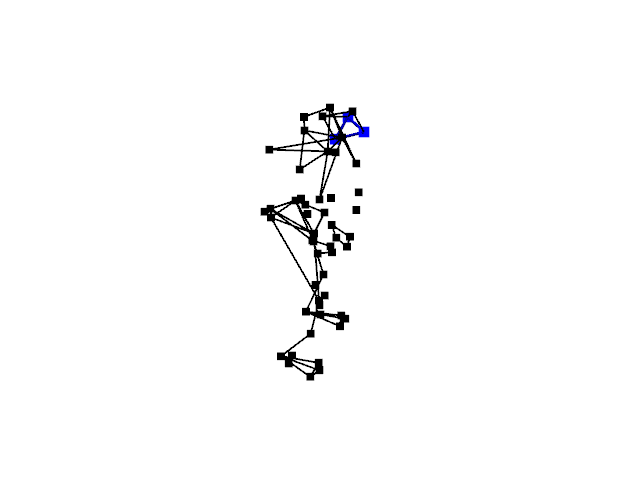

In [1552]:
from IPython.display import Image
Image(filename='animation/original_neck_rotation.gif')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 74.88it/s]


Saved ../../src/ train_dance_text_model/animation/made_neck_rotation.gif and ../../src/ train_dance_text_model/animation/made_neck_rotation.mp4


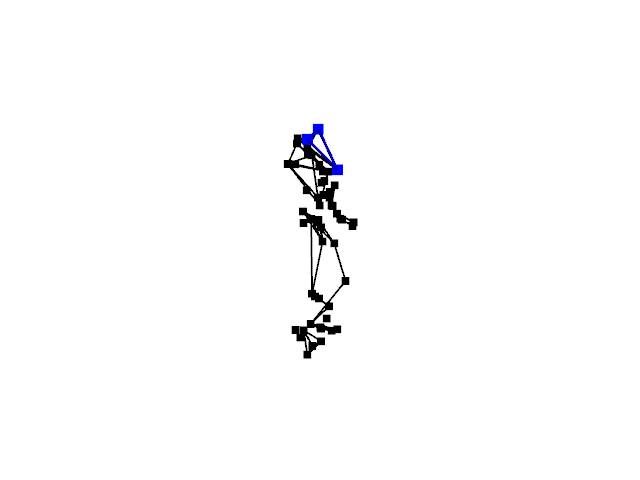

In [1553]:
visualize(motion_autoencoder.decode(text_encoded.detach()).squeeze(0),filename='made_neck_rotation')
from IPython.display import Image
Image(filename='animation/made_neck_rotation.gif')

#### ^^ above is the text to embedding and from that embedding used autoencoder decoder to make the dance again 

# Dance from text 

In [1559]:
# used knn to do this 

In [1660]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1, weights='distance',algorithm='kd_tree')
text_samples = all_labels[:8] # i have only used the 8 eg as i labelled 10 of them and the rest 2 are for validation 
text_emb = torch.cat([get_bert_embedding(text) for text in text_samples], dim=0)
text_latent = text_mapper(text_emb)
knn.fit(text_latent.detach(), all_labels[:8])

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=1, weights='distance')

In [1690]:
all_labels[11]

'spin with right hand above'

In [1692]:
encoded_dance = motion_autoencoder.encode(data[11:12])
predicted_labels = knn.predict(encoded_dance.detach())
predicted_labels.item() # the label predicted 

'spin with little hand movement'

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 72.56it/s]


Saved ../../src/ train_dance_text_model/animation/spin with right hand above.gif and ../../src/ train_dance_text_model/animation/spin with right hand above.mp4


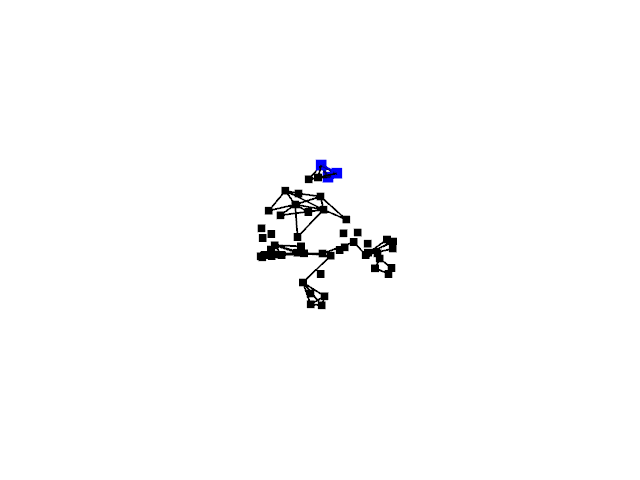

In [1694]:
visualize(motion_autoencoder.decode(encoded_dance).squeeze(0),filename='spin with right hand above')
from IPython.display import Image
Image(filename='animation/spin with right hand above.gif')